### 過学習が可能であることを確認(最低限学習データは学習できること)

学習画像枚数80枚、Epoch100で学習した。    
汎化性はないものの、学習データに対しては最低限学習できていることを確認できた。  
よって、モデル内の計算やオプティマイザーに問題がある可能性は低い  

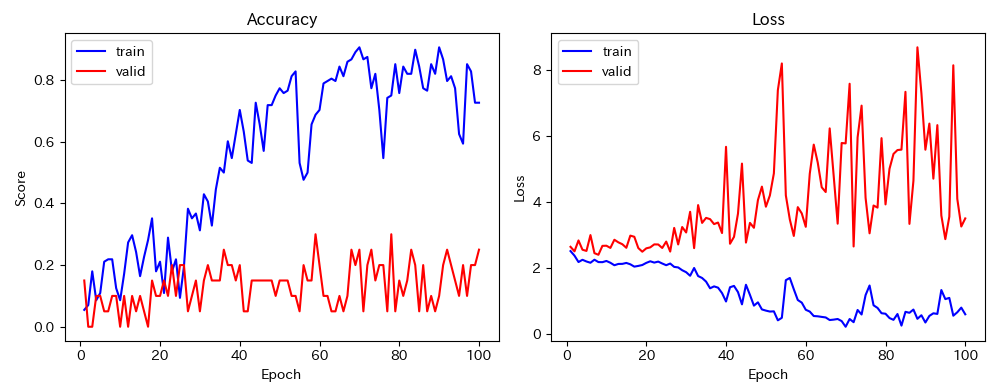
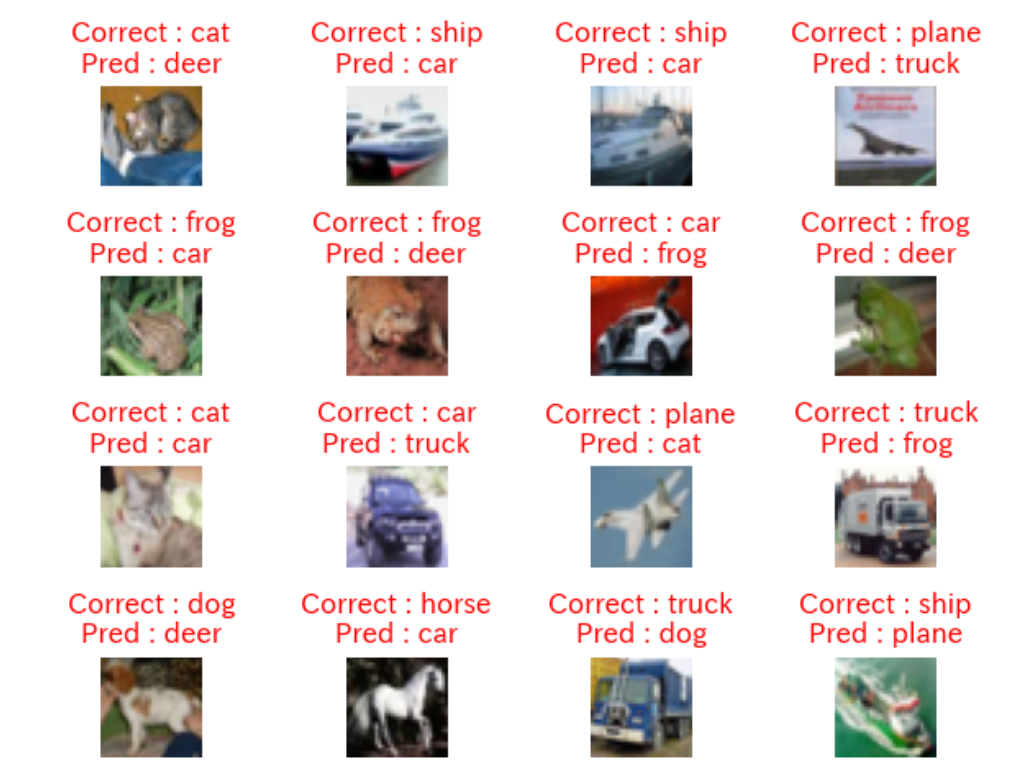

### 汎化性能の問題に焦点を当てる

1. 学習データを100枚→500枚→1000枚→5000枚と増やしたとき、Train/Validation Accuracyがどう変化するか。
2. データ拡張（RandomCrop、RandomHorizontalFlipなど）を使っているか。
3. 学習率が適切か（高すぎても低すぎても汎化しにくくなります）。
4. モデル容量がデータ量に対して大きすぎないか。

### データ数を変えてみる

#### Train images 800, Valid images 200 Max Epoch 10
学習・検証のどちらも正解率、損失が改善している途中で終わっているように見える。  
データ数は変えずにエポックを増やすと汎化性能が上がらないだろうか？  

ただ、800枚学習してAccuracyが23%であるため、精度は低いといえる。  
一先ず、100エポックまで学習して、うまく精度が上がらないようであれば以下の点を調査する。

- 学習率
- モデルの容量(チャネル数、層数)は十分か
- 重み初期化に問題はないか
- Optimizerの計算


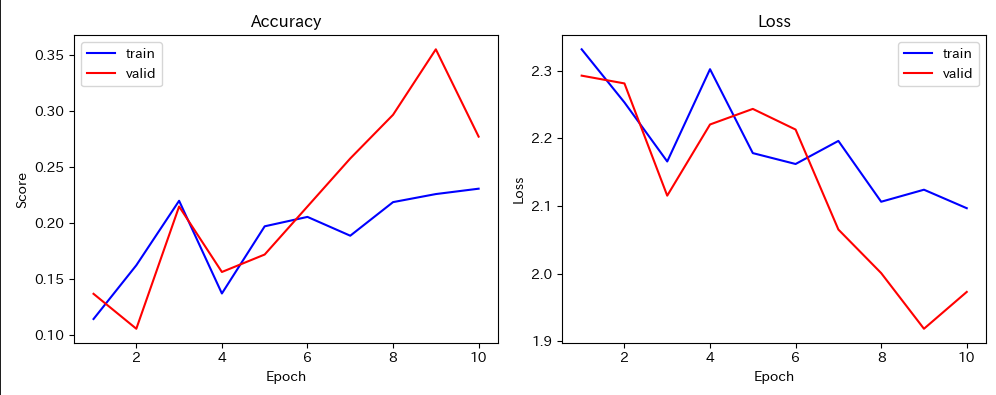

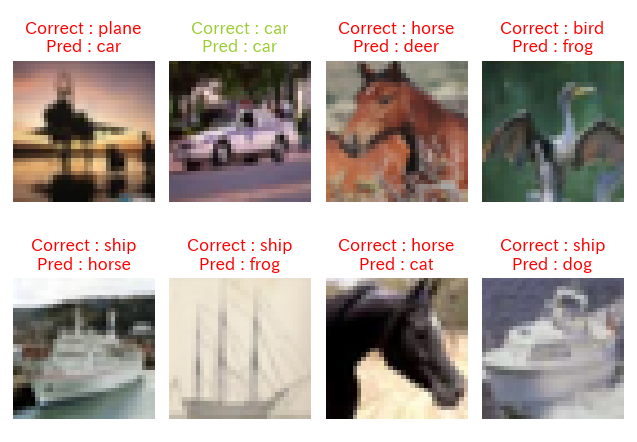

#### Train images 800, Valid images 200 Max Epoch 100

20エポックあたりからAccuracy, Lossともに学習データと検証データで結果が大きく乖離している。  
つまり、過学習が起きていると考えられる。  
また、検証データについてはAccuracyは上がったものの、Lossは下がっていることから、正解する確率は上がったが、モデルが予測に過剰に自信を持つようになったためLossは大きくなっている
- 学習データと検証データに存在するラベルの分布に違いがある？学習データにはCarのデータが多いが検証データにはshipが多いとか。
>CIFAR-10を通常の方法（ランダムシャッフル後にtrain/validへ分割）で分割しているなら、この可能性は低い



##### 学習データ
Accuracy : 10% → 80%  
loss     : 2.3 → 0.5  

##### 検証データ
Accuracy : 10% → 30%  
loss     : 2.3 → 3  

Testデータに対する評価 : Accuracy : 23.44%, Loss : 3.3696722984313965

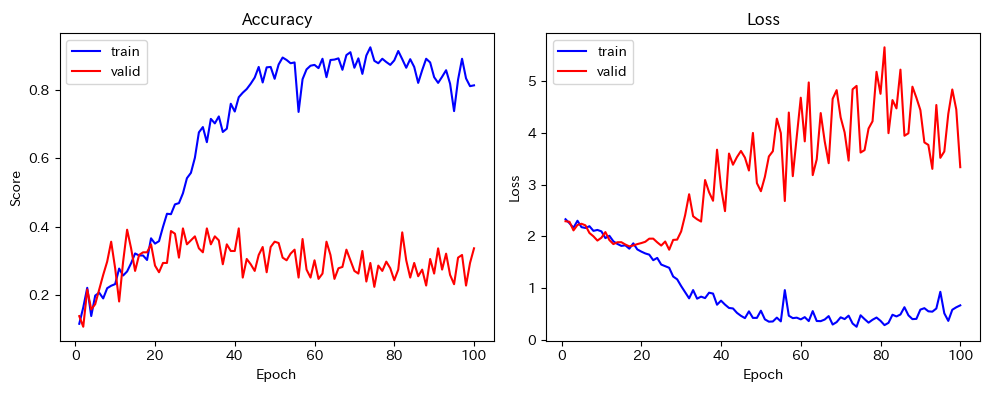
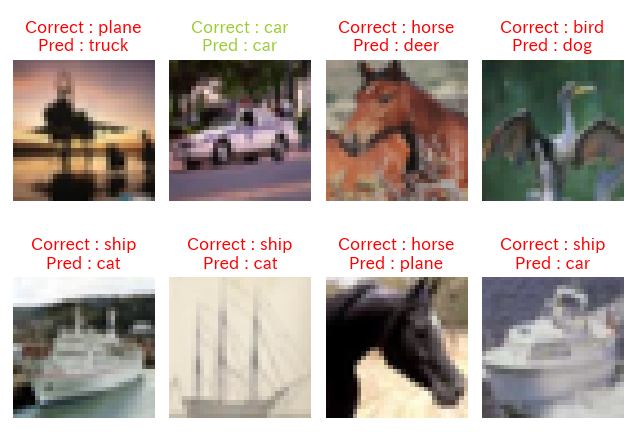

### 使用しているデータを観察する

1. クラスごとの正解率を確認する(学習・検証)  
→どのクラスが得意でどのクラスが苦手か分析  
- どのクラスに対しても60%以上の正解率がある。ある程度まんべんなく各クラスの特徴を学習していると考えられる
- frogとcarについては、75%程の正解率がある。
- bard, cat, deer, dog, については動物同士で外観が類似していることもありやや正解率が低く、60%程度となっている。(3.のグラフを見ると、他のラベルに対して10個ほどラベルが少ないためデータの数が影響していそう)
- 検証では、クラス間の正解率の差が激しい(15% ~ 45%)
- 学習に比べて検証では全体的に正解率が減少しており、過学習の状態にあると推測できる

2. 混同行列を見る(学習・検証)  
→正解に対する予測を可視化できるため、似たクラスを分類できていないかどうかや、完全にランダムかどうかを調べることができる  
- 学習については、右斜めのラインに色が濃くなっており、おおよそ正しく予測できているが一部のクラス間ではご分類も多くみられる。
- 検証時には、plane, car, frog, horseなどには正しく予測できている回数が多いものの、他のラベルに対する予測はまちまちである。  
 ※データ数がラベルごとに異なることも関係していそう(birdの正解率は20%弱なのに混同行列では予測値と真値の領域の色が濃くなっている)
 - 検証時のご分類
    - bird: deerやfrogと混同する傾向にある
    - cat: frogと混同する傾向にある
    - deer: birdとfrogと混同する傾向にある
    - dog : catとfrogと混同する傾向にある
    - ship : planeと混同する傾向にある
    - truck : catと行動している
- 学習データと比べると検証データでは、対角成分が全体的に減少しており、一部のクラスで過学習または汎化性能の不足が生じている可能性がある。
3. 学習データと検証データのラベルの分布を可視化する(学習・検証)  
→学習しているデータに偏りがあることで特定のラベルにのみ、分類が得意になっていないか調査  
- 学習用のデータセットは、ある程度まんべんなく各クラスの個数が揃っているため、学習データの不均衡が原因で、一部のクラスだけ極端に学習されている可能性は低い

#### まとめ
混同行列を見ると、  
bird → deer  
cat → frog  
deer → frog  
dog → frog  
ship → plane  
truck → car  
と誤分類しているため、見た目が似たクラス同士で似ているものと誤分類している。

一方で、学習データに対してはある程度うまく学習できていた。  
これは、すでに学習済みのデータに対する予測を各epochで行っていたためと考えられる。  
検証では全体的に正解率が低かった。  
これは、学習データで学習した特徴が汎化できるものでなかったことを指している。  
例えば、本来鳥は羽やくちばしを見て鳥と分類してほしいが、背景画像やその他鳥とは直接的に関係のない特徴を基に鳥と判定していたと考えられる。  
その証拠に、学習時においても誤分類は30 ~ 40%程発生しており、十分に予測できていないことが確認できる。  
特に外見的に似たクラス同士は誤分類が多く発生している。

つまり、使用しているデータの偏りではなく、**クラス間の特徴の類似性**や**モデルの表現力**が原因で汎化性能が不足していると考えられる。

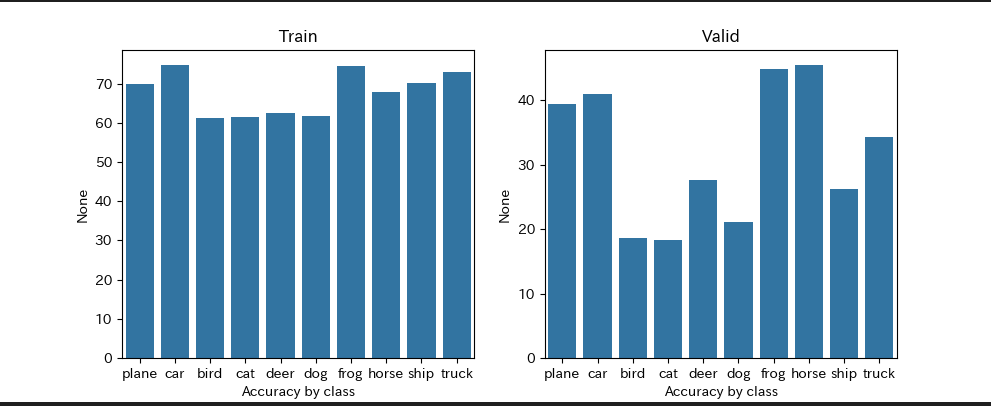

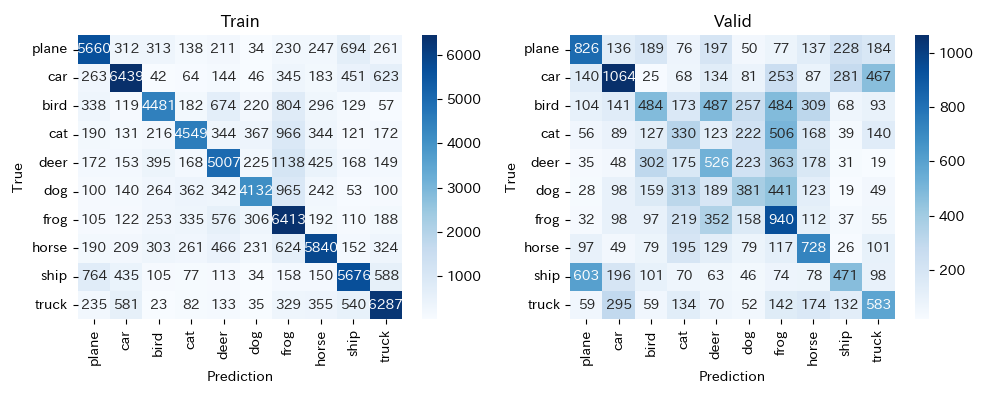

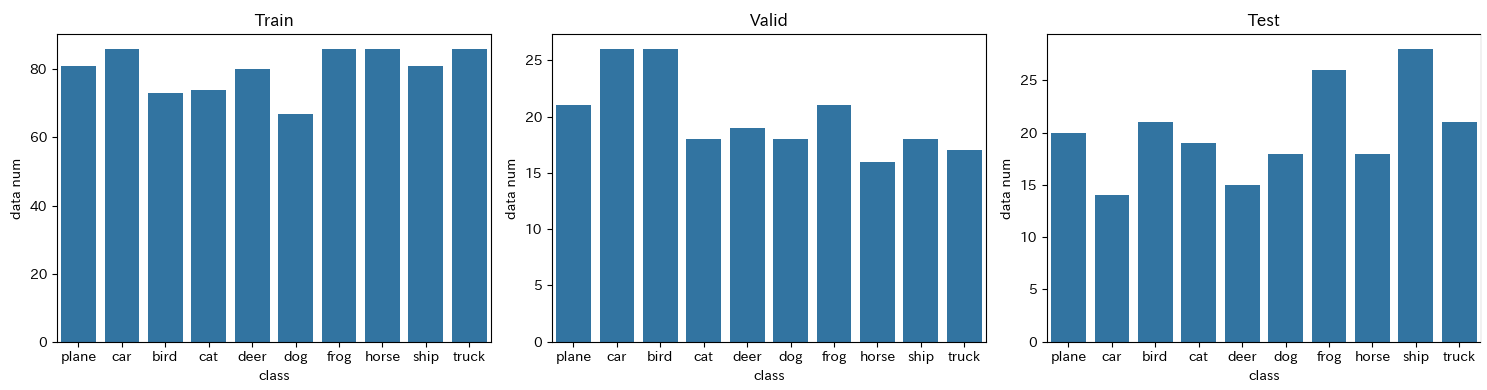

### 今後の対応方針

#### 現在のminiVGGを改善
1. Convブロックを増やす
2. BatchNormを追加
3. Weight Decayを導入
4. Data Augmentationを追加
5. 混同行列・クラス別Accuracyを再評価
どの改善が最も効果的だったか比較する

### ConvolutionにおけるHeの初期化

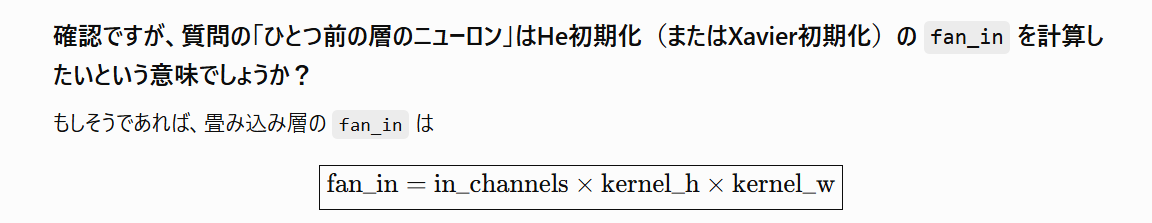

### Dropoutのコードを修正(左最初の学習結果, 右Dropoutのコード修正後)
Dropoutのレイヤーのコードを修正し、学習時と推論時で計算方法が異なるように変更

- 学習・検証用データに対しても正解率は下がっている。
Dropoutが正常に機能するようになったことで学習データ特有の特徴に強く反応し予測することが減ったためと考えられる(良くも悪くも)

- 混同行列は大幅には変化がないが、学習データについては若干予測にばらつきが増えたように思える。Dropoutによりより汎用的な特徴抽出を試みた代償と考えられる
- Epochごとの正解率については、下がる形となったが損失については学習データ検証データともに下がる結果となった。  
これは、モデルが学習データ固有の特徴を過剰に学習し、過剰に自信を持って間違うことが減ったと考えられる。  
つまり、過学習が抑えられている

#### まとめ
Dropoutのコードを修正したことで、過学習が少し抑えられたことを確認できた。  
しかし、正解率に関しては低いままでむしろ当初より下がった。  
これは、モデルがより汎用的な特徴を学習しようとした代償と考えられるが、さらに良いモデルを作るために次は何を試そうか？

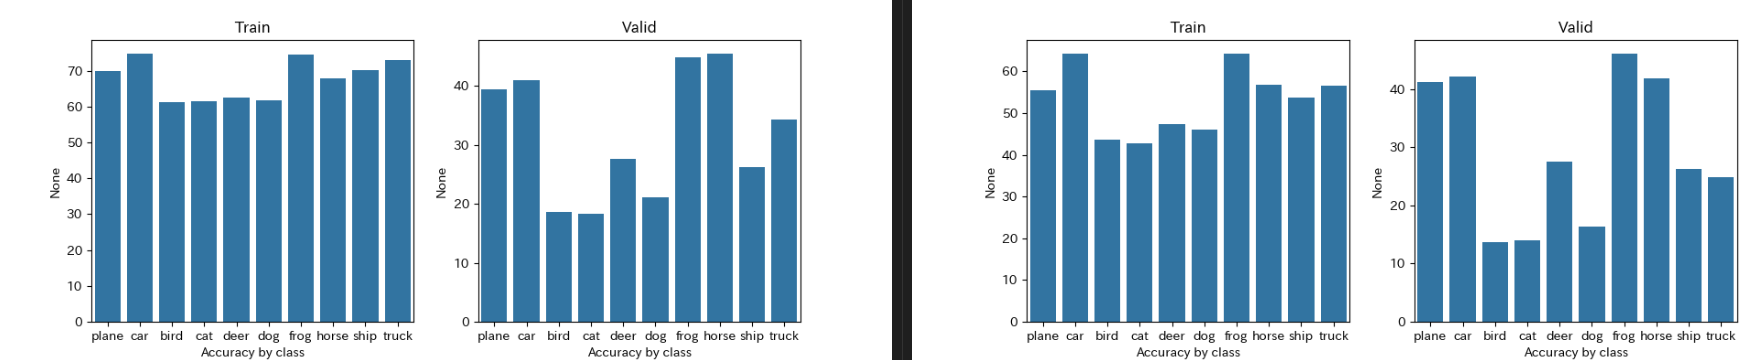
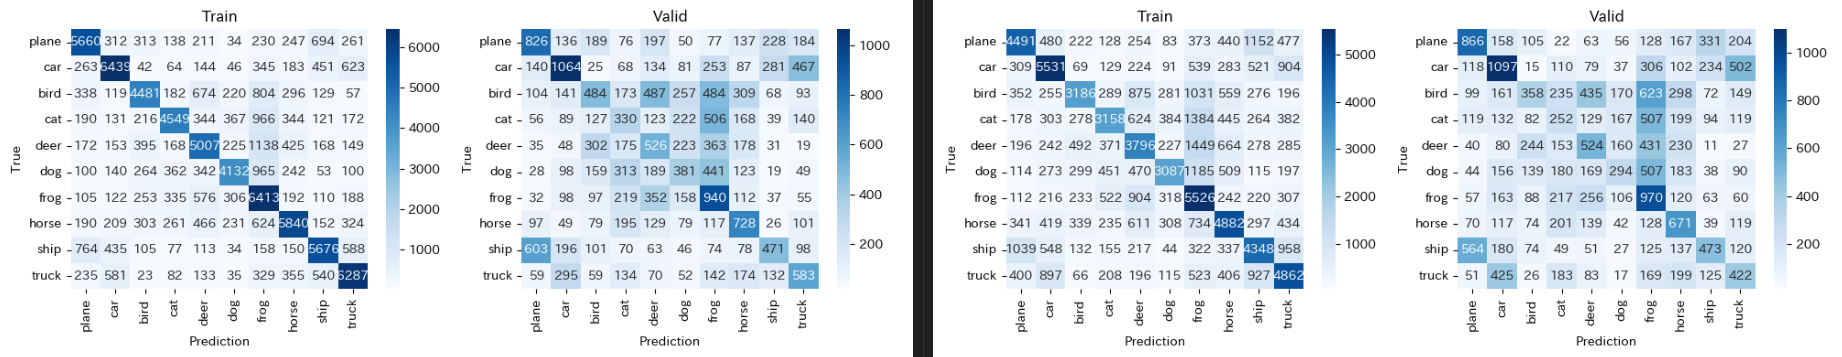
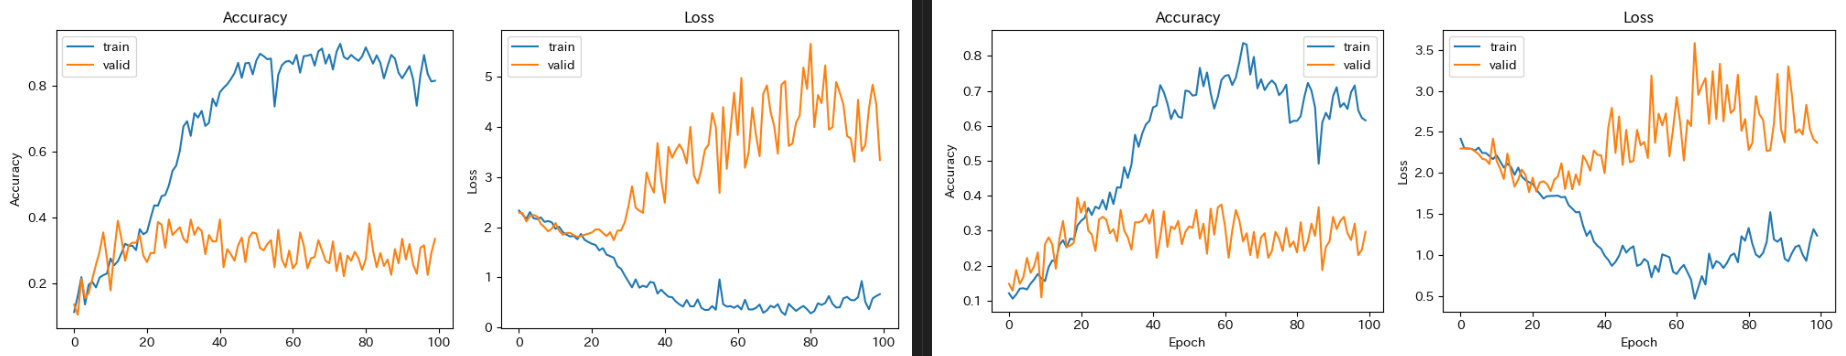